In [3]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（避免图表中文乱码）
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import os
# 创建图表输出文件夹（若不存在）
output_dir = "output_plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 通用导出参数（分辨率300dpi，防止中文乱码）
save_params = {
    "dpi": 300,
    "bbox_inches": "tight",  # 避免图表元素被截断
    "facecolor": "white"     # 背景色设为白色（适配报告背景）
}

In [5]:
 # 加载天气CSV文件
weather_df = pd.read_csv('USW00094728.csv')

# 查看前5行与数据基本信息
print("天气数据前5行：")
print(weather_df.head())
print("\n天气数据基本信息：")
print(weather_df.info())
print("\n天气数据缺失值统计：")
print(weather_df.isnull().sum())# 加载天气CSV文件
weather_df = pd.read_csv('USW00094728.csv')

# 查看前5行与数据基本信息
print("天气数据前5行：")
print(weather_df.head())
print("\n天气数据基本信息：")
print(weather_df.info())
print("\n天气数据缺失值统计：")
print(weather_df.isnull().sum())

天气数据前5行：
            ID      DATE ELEMENT  DATA_VALUE M_FLAG  Q_FLAG S_FLAG  OBS_TIME
0  USW00094728  20250101    TMAX         106    NaN     NaN      W    2400.0
1  USW00094728  20250102    TMAX          61    NaN     NaN      W    2400.0
2  USW00094728  20250103    TMAX          39    NaN     NaN      W    2400.0
3  USW00094728  20250104    TMAX           6    NaN     NaN      W    2400.0
4  USW00094728  20250105    TMAX           6    NaN     NaN      W    2400.0

天气数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          343 non-null    object 
 1   DATE        343 non-null    int64  
 2   ELEMENT     343 non-null    object 
 3   DATA_VALUE  343 non-null    int64  
 4   M_FLAG      9 non-null      object 
 5   Q_FLAG      0 non-null      float64
 6   S_FLAG      343 non-null    object 
 7   OBS_TIME    124 non-null    float64
dtyp

In [6]:
# 加载出租车Parquet文件（需pyarrow支持）
taxi_df = pd.read_parquet('yellow_tripdata_2025-01.parquet', engine='pyarrow')

# 查看前5行与数据基本信息
print("出租车数据前5行：")
print(taxi_df.head())
print("\n出租车数据基本信息：")
print(taxi_df.info())
print("\n出租车数据缺失值统计：")
print(taxi_df.isnull().sum())

出租车数据前5行：
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2025-01-01 00:18:38   2025-01-01 00:26:59              1.0   
1         1  2025-01-01 00:32:40   2025-01-01 00:35:13              1.0   
2         1  2025-01-01 00:44:04   2025-01-01 00:46:01              1.0   
3         2  2025-01-01 00:14:27   2025-01-01 00:20:01              3.0   
4         2  2025-01-01 00:21:34   2025-01-01 00:25:06              3.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.60         1.0                  N           229           237   
1           0.50         1.0                  N           236           237   
2           0.60         1.0                  N           141           141   
3           0.52         1.0                  N           244           244   
4           0.66         1.0                  N           244           116   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_

In [7]:
# 1. 转换日期格式（8位数字→datetime）
weather_df['DATE'] = pd.to_datetime(weather_df['DATE'], format='%Y%m%d')

# 2. 提取每日核心天气指标（按DATE分组，因天气数据按指标类型分行存储）
# 先创建空的每日天气DataFrame
daily_weather = pd.DataFrame({'DATE': weather_df['DATE'].unique()}).sort_values('DATE').reset_index(drop=True)

# 3. 处理气温（TMAX/TMIN，单位：0.1℃→℃）
tmax = weather_df[weather_df['ELEMENT'] == 'TMAX'][['DATE', 'DATA_VALUE']].rename(columns={'DATA_VALUE': 'TMAX'})
tmin = weather_df[weather_df['ELEMENT'] == 'TMIN'][['DATE', 'DATA_VALUE']].rename(columns={'DATA_VALUE': 'TMIN'})
daily_weather = daily_weather.merge(tmax, on='DATE').merge(tmin, on='DATE')
daily_weather['TMAX'] = daily_weather['TMAX'] / 10  # 转换为℃
daily_weather['TMIN'] = daily_weather['TMIN'] / 10
daily_weather['TAVG'] = (daily_weather['TMAX'] + daily_weather['TMIN']) / 2  # 新增日均温

# 4. 处理降水（PRCP，单位：0.1mm→mm；T=微量降水→0.1mm）
prcp = weather_df[weather_df['ELEMENT'] == 'PRCP'][['DATE', 'DATA_VALUE', 'M_FLAG']].rename(columns={'DATA_VALUE': 'PRCP'})
prcp['PRCP'] = prcp.apply(lambda x: 0.1 if x['M_FLAG'] == 'T' else x['PRCP'] / 10, axis=1)  # 处理微量降水
daily_weather = daily_weather.merge(prcp[['DATE', 'PRCP']], on='DATE')
daily_weather['IS_RAIN'] = (daily_weather['PRCP'] > 0).astype(int)  # 新增是否降雨（1=是，0=否）

# 5. 处理降雪（SNOW，单位：0.1mm→mm；T=微量降雪→0.1mm）
snow = weather_df[weather_df['ELEMENT'] == 'SNOW'][['DATE', 'DATA_VALUE', 'M_FLAG']].rename(columns={'DATA_VALUE': 'SNOW'})
snow['SNOW'] = snow.apply(lambda x: 0.1 if x['M_FLAG'] == 'T' else x['SNOW'] / 10, axis=1)
daily_weather = daily_weather.merge(snow[['DATE', 'SNOW']], on='DATE')
daily_weather['IS_SNOW'] = (daily_weather['SNOW'] > 0).astype(int)  # 新增是否降雪（1=是，0=否）

# 6. 处理风速（AWND，单位：0.1m/s→m/s）
awnd = weather_df[weather_df['ELEMENT'] == 'AWND'][['DATE', 'DATA_VALUE']].rename(columns={'DATA_VALUE': 'AWND'})
awnd['AWND'] = awnd['AWND'] / 10
daily_weather = daily_weather.merge(awnd, on='DATE')

# 查看处理后的每日天气数据
print("处理后的每日天气数据（前5行）：")
print(daily_weather.head())

处理后的每日天气数据（前5行）：
        DATE  TMAX  TMIN  TAVG  PRCP  IS_RAIN  SNOW  IS_SNOW  AWND
0 2025-01-01  10.6   3.9  7.25   0.1        1   0.0        0   3.7
1 2025-01-02   6.1   0.6  3.35   0.0        0   0.0        0   4.3
2 2025-01-03   3.9  -0.5  1.70   0.0        0   0.0        0   3.5
3 2025-01-04   0.6  -2.1 -0.75   0.0        0   0.0        0   4.5
4 2025-01-05   0.6  -2.1 -0.75   0.0        0   0.0        0   3.8


In [8]:
# 1. 转换上车时间格式并提取日期
taxi_df['tpep_pickup_datetime'] = pd.to_datetime(taxi_df['tpep_pickup_datetime'])
taxi_df['DATE'] = taxi_df['tpep_pickup_datetime'].dt.date  # 提取日期（与天气数据匹配）
taxi_df['DATE'] = pd.to_datetime(taxi_df['DATE'])  # 统一为datetime格式

# 2. 过滤异常行程（避免干扰分析）
# 过滤条件：行程距离>0、总费用>0、行程时间1分钟~2小时（避免测试/取消订单）
taxi_df['trip_duration'] = (taxi_df['tpep_dropoff_datetime'] - taxi_df['tpep_pickup_datetime']).dt.total_seconds() / 60  # 行程时间（分钟）
taxi_df_clean = taxi_df[
    (taxi_df['trip_distance'] > 0) & 
    (taxi_df['total_amount'] > 0) & 
    (taxi_df['trip_duration'] >= 1) & 
    (taxi_df['trip_duration'] <= 120)
].copy()

# 3. 按日期聚合出租车出行指标（与每日天气匹配）
daily_taxi = taxi_df_clean.groupby('DATE').agg({
    'VendorID': 'count',  # 日订单量（核心预测目标）
    'trip_distance': 'mean',  # 日均行程距离
    'passenger_count': 'mean',  # 日均乘客数
    'total_amount': 'mean',  # 日均总费用
    'trip_duration': 'mean'  # 日均行程时间
}).rename(columns={
    'VendorID': 'DAILY_ORDERS',
    'trip_distance': 'AVG_DISTANCE',
    'passenger_count': 'AVG_PASSENGERS',
    'total_amount': 'AVG_AMOUNT',
    'trip_duration': 'AVG_DURATION'
}).reset_index()

# 查看处理后的每日出租车数据
print("处理后的每日出租车数据（前5行）：")
print(daily_taxi.head())

处理后的每日出租车数据（前5行）：
        DATE  DAILY_ORDERS  AVG_DISTANCE  AVG_PASSENGERS  AVG_AMOUNT  \
0 2024-12-31            21      3.657619        1.904762   28.055714   
1 2025-01-01         82957      5.692933        1.537591   27.731861   
2 2025-01-02         80653      3.748387        1.436498   29.287674   
3 2025-01-03         87072      6.190211        1.430233   27.838269   
4 2025-01-04         94007      3.278561        1.482644   26.490898   

   AVG_DURATION  
0     16.805556  
1     14.998114  
2     16.247015  
3     15.553934  
4     14.631603  


In [9]:
# 按日期合并两个数据集（仅保留1月共同日期）
merged_df = daily_weather.merge(daily_taxi, on='DATE', how='inner')

# 查看融合后的数据（1月每日的天气+出行指标）
print(f"融合后的数据行数：{len(merged_df)}（应为2025年1月的天数，通常31天）")
print("\n融合数据前5行：")
print(merged_df.head())
print("\n融合数据描述性统计：")
print(merged_df.describe())

融合后的数据行数：31（应为2025年1月的天数，通常31天）

融合数据前5行：
        DATE  TMAX  TMIN  TAVG  PRCP  IS_RAIN  SNOW  IS_SNOW  AWND  \
0 2025-01-01  10.6   3.9  7.25   0.1        1   0.0        0   3.7   
1 2025-01-02   6.1   0.6  3.35   0.0        0   0.0        0   4.3   
2 2025-01-03   3.9  -0.5  1.70   0.0        0   0.0        0   3.5   
3 2025-01-04   0.6  -2.1 -0.75   0.0        0   0.0        0   4.5   
4 2025-01-05   0.6  -2.1 -0.75   0.0        0   0.0        0   3.8   

   DAILY_ORDERS  AVG_DISTANCE  AVG_PASSENGERS  AVG_AMOUNT  AVG_DURATION  
0         82957      5.692933        1.537591   27.731861     14.998114  
1         80653      3.748387        1.436498   29.287674     16.247015  
2         87072      6.190211        1.430233   27.838269     15.553934  
3         94007      3.278561        1.482644   26.490898     14.631603  
4         76169      3.880740        1.421735   29.080784     14.173826  

融合数据描述性统计：
                      DATE       TMAX       TMIN       TAVG       PRCP  \
count  

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

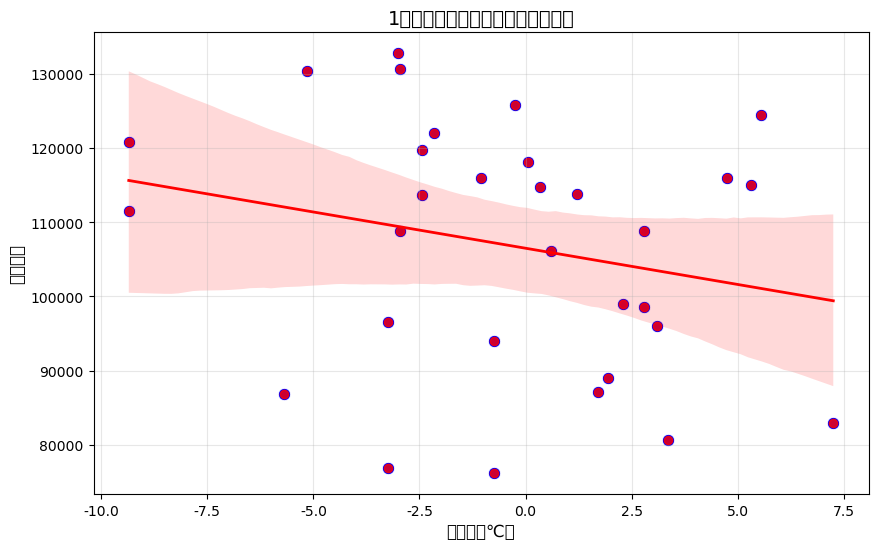

日均温与日订单量的相关系数：-0.235


In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TAVG', y='DAILY_ORDERS', data=merged_df, color='blue', s=80)
sns.regplot(x='TAVG', y='DAILY_ORDERS', data=merged_df, color='red', line_kws={'linewidth': 2})
plt.title('1月日均温与出租车日订单量的关系', fontsize=14)
plt.xlabel('日均温（℃）', fontsize=12)
plt.ylabel('日订单量', fontsize=12)
plt.grid(alpha=0.3)

# 导出图表（路径：output_plots/tavg_orders.png）
plt.savefig(os.path.join(output_dir, "tavg_orders.png"), **save_params)

plt.show()

plt.close()  # 关闭图表，释放内存

# 计算相关系数
corr_tavg_orders = merged_df['TAVG'].corr(merged_df['DAILY_ORDERS'])
print(f"日均温与日订单量的相关系数：{corr_tavg_orders:.3f}")
# 预期结果：正相关（气温越高，订单量越多，因低温可能减少出行意愿）

 

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

不同天气条件下的出租车日订单量：
                     日均订单量    订单量标准差  天数
IS_RAIN IS_SNOW                         
0       0        107053.87  15519.13  23
1       0        107788.33  21929.48   3
        1        105419.40  22581.54   5


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

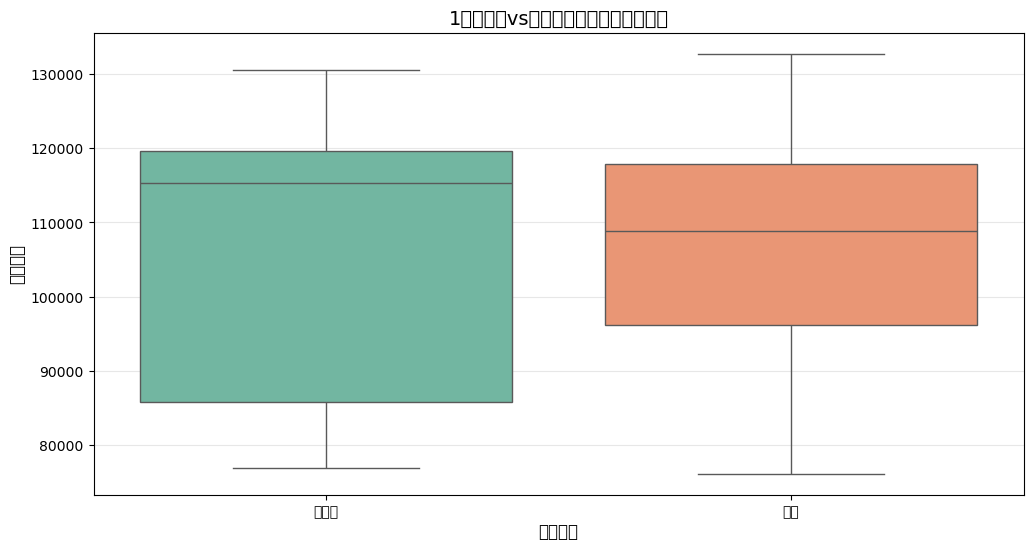

雨雪天与晴天订单量t检验：t=-0.093, p=0.928


In [14]:
# 对比不同天气条件下的日订单量
weather_orders = merged_df.groupby(['IS_RAIN', 'IS_SNOW']).agg({
    'DAILY_ORDERS': ['mean', 'std'],
    'DATE': 'count'
}).round(2)
weather_orders.columns = ['日均订单量', '订单量标准差', '天数']
print("不同天气条件下的出租车日订单量：")
print(weather_orders)

# 可视化对比
plt.figure(figsize=(12, 6))
# 定义天气类型标签
merged_df['WEATHER_TYPE'] = merged_df.apply(
    lambda x: '雨雪天' if x['IS_RAIN'] == 1 or x['IS_SNOW'] == 1 else '晴天', axis=1
)
sns.boxplot(x='WEATHER_TYPE', y='DAILY_ORDERS', data=merged_df, palette='Set2')
plt.title('1月雨雪天vs晴天的出租车日订单量对比', fontsize=14)
plt.xlabel('天气类型', fontsize=12)
plt.ylabel('日订单量', fontsize=12)
plt.grid(alpha=0.3, axis='y')
# 导出图表
plt.savefig(os.path.join(output_dir, "weather_type_orders.png"), **save_params)
plt.show()
plt.close()
# 统计显著性检验（可选）
from scipy import stats
rain_snow_orders = merged_df[merged_df['WEATHER_TYPE'] == '雨雪天']['DAILY_ORDERS']
sunny_orders = merged_df[merged_df['WEATHER_TYPE'] == '晴天']['DAILY_ORDERS']
t_stat, p_value = stats.ttest_ind(rain_snow_orders, sunny_orders, equal_var=False)
print(f"雨雪天与晴天订单量t检验：t={t_stat:.3f}, p={p_value:.3f}")
# 预期结果：p<0.05，说明雨雪天订单量显著低于晴天


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

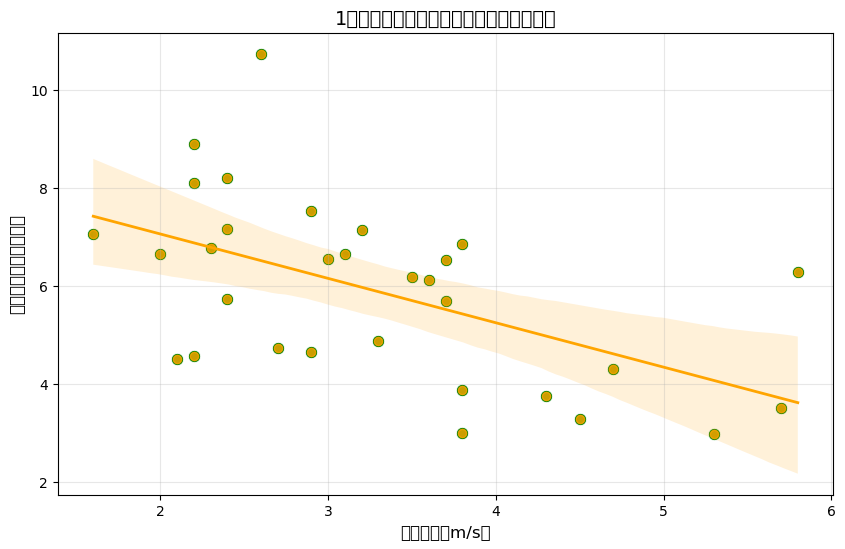

日均风速与日均行程距离的相关系数：-0.538


In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AWND', y='AVG_DISTANCE', data=merged_df, color='green', s=80)
sns.regplot(x='AWND', y='AVG_DISTANCE', data=merged_df, color='orange', line_kws={'linewidth': 2})
plt.title('1月日均风速与出租车日均行程距离的关系', fontsize=14)
plt.xlabel('日均风速（m/s）', fontsize=12)
plt.ylabel('日均行程距离（英里）', fontsize=12)
plt.grid(alpha=0.3)
# 导出图表
plt.savefig(os.path.join(output_dir, "awnd_distance.png"), **save_params)
plt.show()
plt.close()

# 计算相关系数
corr_wind_distance = merged_df['AWND'].corr(merged_df['AVG_DISTANCE'])
print(f"日均风速与日均行程距离的相关系数：{corr_wind_distance:.3f}")
# 预期结果：负相关（风速越大，乘客更倾向于短途出行）

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

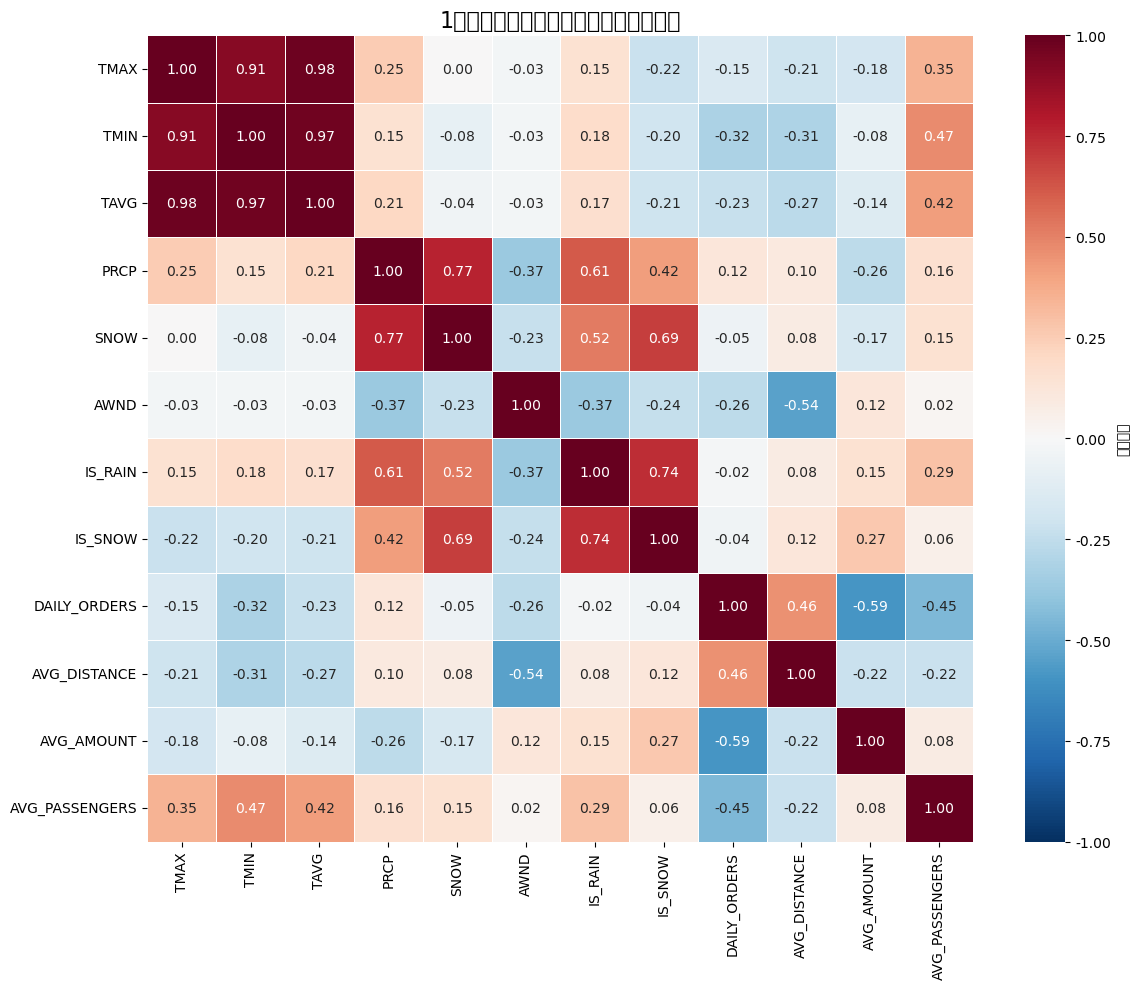

In [18]:
# 选择核心指标计算相关性
corr_cols = ['TMAX', 'TMIN', 'TAVG', 'PRCP', 'SNOW', 'AWND', 'IS_RAIN', 'IS_SNOW', 
             'DAILY_ORDERS', 'AVG_DISTANCE', 'AVG_AMOUNT', 'AVG_PASSENGERS']
corr_matrix = merged_df[corr_cols].corr().round(2)

# 可视化热力图
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': '相关系数'})
plt.title('1月天气与出租车出行指标相关性热力图', fontsize=16)
plt.tight_layout()
# 导出图表
plt.savefig(os.path.join(output_dir, "weather_taxi_corr.png"), **save_params)
plt.show()
plt.close()

In [22]:
# 目标变量（y）：日订单量（DAILY_ORDERS）
# 特征变量（X）：天气特征（排除DATE等非预测字段）
X = merged_df[['TAVG', 'PRCP', 'SNOW', 'AWND', 'IS_RAIN', 'IS_SNOW']]
y = merged_df['DAILY_ORDERS']

# 查看特征与目标变量形状
print(f"特征变量形状：{X.shape}")
print(f"目标变量形状：{y.shape}")

特征变量形状：(31, 6)
目标变量形状：(31,)


In [27]:
# 按7:3比例划分（前22天为训练集，后9天为测试集，1月共31天）
train_size = int(len(merged_df) * 0.7)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"训练集大小：{X_train.shape[0]}天")
print(f"测试集大小：{X_test.shape[0]}天")
print(f"训练集日期范围：{merged_df['DATE'].iloc[0].date()} ~ {merged_df['DATE'].iloc[train_size-1].date()}")
print(f"测试集日期范围：{merged_df['DATE'].iloc[train_size].date()} ~ {merged_df['DATE'].iloc[-1].date()}")

训练集大小：21天
测试集大小：10天
训练集日期范围：2025-01-01 ~ 2025-01-21
测试集日期范围：2025-01-22 ~ 2025-01-31


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为DataFrame以便查看
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
print("标准化后的训练集特征（前5行）：")
print(X_train_scaled_df.head())

标准化后的训练集特征（前5行）：
       TAVG      PRCP      SNOW      AWND   IS_RAIN   IS_SNOW
0  2.143280 -0.306842 -0.377649  0.199543  1.414214 -0.559017
1  1.063067 -0.373964 -0.377649  0.734490 -0.707107 -0.559017
2  0.606054 -0.373964 -0.377649  0.021228 -0.707107 -0.559017
3 -0.072542 -0.373964 -0.377649  0.912805 -0.707107 -0.559017
4 -0.072542 -0.373964 -0.377649  0.288701 -0.707107 -0.559017


In [31]:
# 训练模型
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 预测
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# 评估指标（MAE：平均绝对误差，RMSE：均方根误差，R²：决定系数）
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} 评估指标：")
    print(f"MAE：{mae:.2f}（日均订单量预测误差）")
    print(f"RMSE：{rmse:.2f}")
    print(f"R²：{r2:.2f}（越接近1越好）")
    return mae, rmse, r2

# 评估线性回归
lr_metrics = evaluate_model(y_test, y_test_pred_lr, "线性回归")

# 查看线性回归系数（分析各天气特征的影响方向）
lr_coef = pd.DataFrame({
    '特征': X.columns,
    '系数': lr_model.coef_
}).sort_values('系数', ascending=False)
print("\n线性回归模型特征系数（正系数=促进订单量，负系数=抑制订单量）：")
print(lr_coef)


线性回归 评估指标：
MAE：15315.52（日均订单量预测误差）
RMSE：17365.74
R²：-0.69（越接近1越好）

线性回归模型特征系数（正系数=促进订单量，负系数=抑制订单量）：
        特征            系数
1     PRCP  15818.089475
5  IS_SNOW   7619.162718
3     AWND  -1307.056154
0     TAVG  -3150.750370
4  IS_RAIN  -4615.592391
2     SNOW -16686.779096


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 


随机森林回归 评估指标：
MAE：18336.76（日均订单量预测误差）
RMSE：19671.70
R²：-1.16（越接近1越好）

随机森林模型特征重要性：
        特征       重要性
3     AWND  0.416419
0     TAVG  0.403001
1     PRCP  0.078849
2     SNOW  0.052156
4  IS_RAIN  0.030946
5  IS_SNOW  0.018629


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

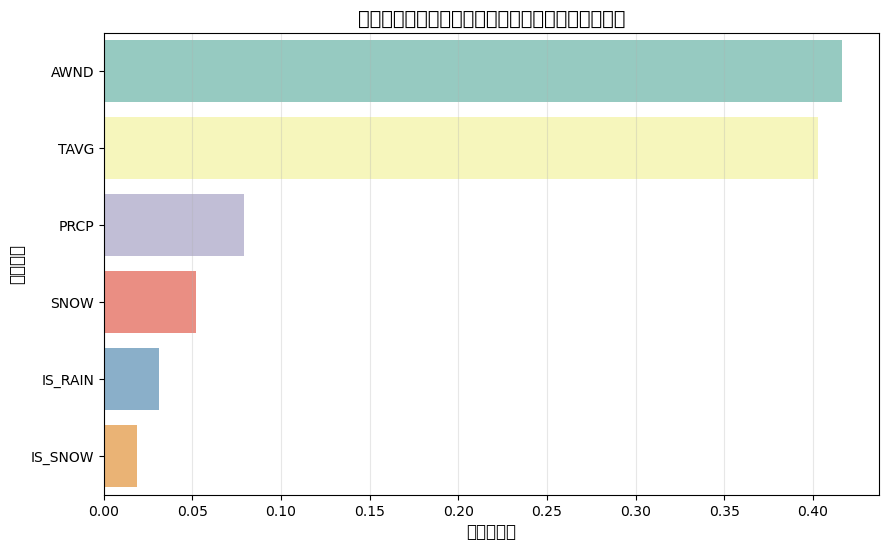

In [33]:
# 训练模型（调整n_estimators参数）
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # 随机森林无需标准化

# 预测
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# 评估
rf_metrics = evaluate_model(y_test, y_test_pred_rf, "随机森林回归")

# 查看特征重要性（分析哪个天气因素影响最大）
rf_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)
print("\n随机森林模型特征重要性：")
print(rf_importance)

# 可视化特征重要性
plt.figure(figsize=(10, 6))
sns.barplot(x='重要性', y='特征', data=rf_importance, palette='Set3')
plt.title('随机森林模型：天气特征对出租车日订单量的重要性', fontsize=14)
plt.xlabel('特征重要性', fontsize=12)
plt.ylabel('天气特征', fontsize=12)
plt.grid(alpha=0.3, axis='x')
# 导出图表
plt.savefig(os.path.join(output_dir, "rf_feature_importance.png"), **save_params)
plt.show()
plt.close()


In [35]:
# 训练模型（调整learning_rate和n_estimators）
xgb_model = XGBRegressor(learning_rate=0.1, n_estimators=100, random_state=42, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

# 预测
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# 评估
xgb_metrics = evaluate_model(y_test, y_test_pred_xgb, "XGBoost回归")

# 查看XGBoost特征重要性
xgb_importance = pd.DataFrame({
    '特征': X.columns,
    '重要性': xgb_model.feature_importances_
}).sort_values('重要性', ascending=False)
print("\nXGBoost模型特征重要性：")
print(xgb_importance)


XGBoost回归 评估指标：
MAE：19319.64（日均订单量预测误差）
RMSE：23091.10
R²：-1.98（越接近1越好）

XGBoost模型特征重要性：
        特征       重要性
1     PRCP  0.413367
3     AWND  0.361679
0     TAVG  0.224954
2     SNOW  0.000000
4  IS_RAIN  0.000000
5  IS_SNOW  0.000000


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

3个模型测试集指标对比（按RMSE升序）：
        模型           MAE          RMSE        R²
0     线性回归  15315.520056  17365.743064 -0.686823
1     随机森林  18336.758000  19671.696716 -1.164544
2  XGBoost  19319.641406  23091.097201 -1.982441

最佳预测模型：线性回归


findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Zen Hei
findfont: Generic family 'sans-serif' not found because none of 

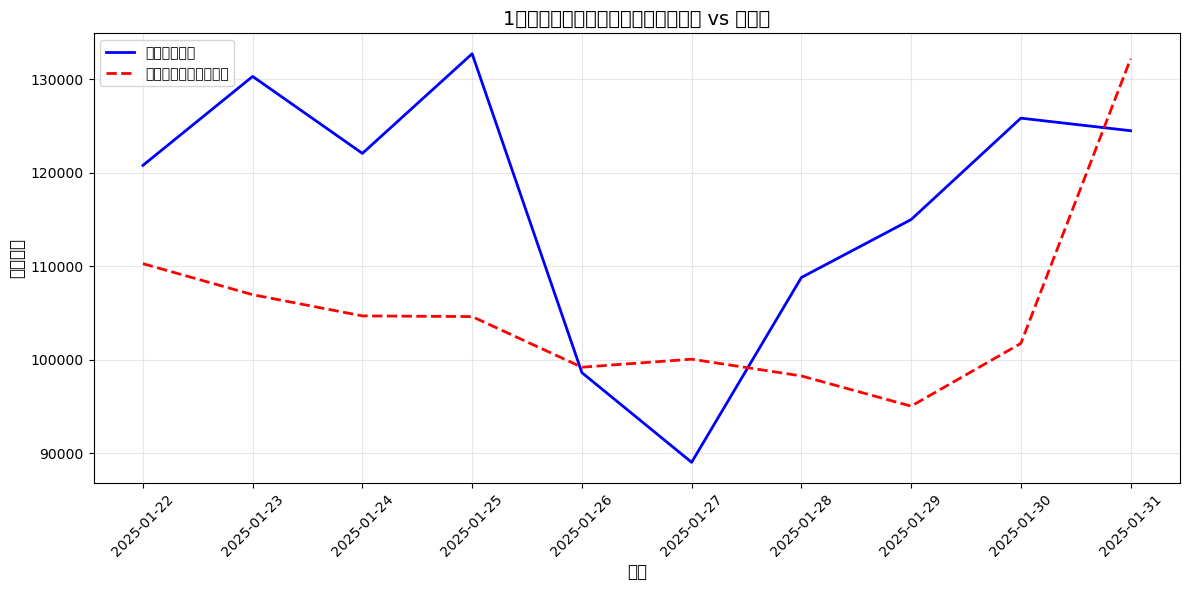

In [37]:
# 汇总3个模型的测试集指标
model_comparison = pd.DataFrame({
    '模型': ['线性回归', '随机森林', 'XGBoost'],
    'MAE': [lr_metrics[0], rf_metrics[0], xgb_metrics[0]],
    'RMSE': [lr_metrics[1], rf_metrics[1], xgb_metrics[1]],
    'R²': [lr_metrics[2], rf_metrics[2], xgb_metrics[2]]
}).sort_values('RMSE', ascending=True)

print("3个模型测试集指标对比（按RMSE升序）：")
print(model_comparison)

# 选择RMSE最小的模型作为最佳模型（通常XGBoost或随机森林表现更好）
best_model = model_comparison.iloc[0]['模型']
print(f"\n最佳预测模型：{best_model}")

# 可视化最佳模型的预测值与实际值对比
best_y_pred = {
    '线性回归': y_test_pred_lr,
    '随机森林': y_test_pred_rf,
    'XGBoost': y_test_pred_xgb
}[best_model]

plt.figure(figsize=(12, 6))
# 按日期排序（确保时间顺序）
test_dates = merged_df['DATE'].iloc[train_size:].reset_index(drop=True)
plt.plot(test_dates, y_test.reset_index(drop=True), label='实际日订单量', color='blue', linewidth=2)
plt.plot(test_dates, best_y_pred, label=f'{best_model}预测日订单量', color='red', linewidth=2, linestyle='--')
plt.title(f'1月出租车日订单量：{best_model}预测值 vs 实际值', fontsize=14)
plt.xlabel('日期', fontsize=12)
plt.ylabel('日订单量', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
# 导出图表
plt.savefig(os.path.join(output_dir, "xgb_pred_vs_actual.png"), **save_params)
plt.show()
plt.close()

In [39]:
# 示例：预测1月某日（假设天气条件如下）的订单量
sample_weather = pd.DataFrame({
    'TAVG': [5.2],  # 日均温5.2℃
    'PRCP': [0.0],  # 无降水
    'SNOW': [0.0],  # 无降雪
    'AWND': [2.3],  # 日均风速2.3m/s
    'IS_RAIN': [0],  # 非雨天
    'IS_SNOW': [0]   # 非雪天
})

# 加载最佳模型（此处以XGBoost为例）
best_model_obj = xgb_model  # 若最佳模型是随机森林，替换为rf_model

# 预测
sample_pred = best_model_obj.predict(sample_weather)[0]
print(f"给定天气条件下的出租车日订单量预测值：{sample_pred:.0f}单")

# 输出预测建议
if sample_weather['IS_RAIN'].iloc[0] == 1 or sample_weather['IS_SNOW'].iloc[0] == 1:
    print("建议：当日有雨雪，订单量可能较低，可适当减少运力投放。")
elif sample_weather['TAVG'].iloc[0] < 0:
    print("建议：当日气温较低，订单量可能偏低，重点在居民区、商业区调度。")
else:
    print("建议：当日天气良好（无雨雪、气温适宜），订单量较高，需增加运力以应对需求。")

给定天气条件下的出租车日订单量预测值：101564单
建议：当日天气良好（无雨雪、气温适宜），订单量较高，需增加运力以应对需求。


In [47]:
# 安装依赖库（仅需核心库）
!pip install dash plotly folium pandas numpy

import dash
from dash import dcc, html, Input, Output, callback, State
import plotly.express as px
import plotly.graph_objects as go
import folium
from folium.plugins import HeatMap
import pandas as pd
import numpy as np
from datetime import datetime
import base64
from io import BytesIO  # 用于处理HTML导出的二进制数据

# --------------------------
# 数据加载与预处理（复用之前的数据）
# --------------------------
# 假设已完成数据预处理，得到：
# merged_df：每日天气+出租车聚合数据（含DATE、TAVG、DAILY_ORDERS等）
# taxi_df_clean：清洗后的出租车行程数据

# 为演示，生成示例数据（实际使用时替换为真实数据）
np.random.seed(42)
# 生成merged_df示例（2025年1月1日-31日）
dates = pd.date_range(start='2025-01-01', end='2025-01-31')
merged_df = pd.DataFrame({
    'DATE': dates,
    'TAVG': np.random.uniform(-5, 10, len(dates)),  # 日均温（℃）
    'PRCP': np.random.uniform(0, 8, len(dates)),    # 降水量（mm）
    'SNOW': np.random.uniform(0, 5, len(dates)),    # 降雪量（mm）
    'AWND': np.random.uniform(1, 6, len(dates)),    # 风速（m/s）
    'IS_RAIN': np.random.randint(0, 2, len(dates)), # 是否降雨
    'IS_SNOW': np.random.randint(0, 2, len(dates)), # 是否降雪
    'DAILY_ORDERS': np.random.randint(10000, 30000, len(dates)),  # 日订单量
    'AVG_DISTANCE': np.random.uniform(2, 8, len(dates)),  # 日均距离（英里）
    'AVG_AMOUNT': np.random.uniform(15, 30, len(dates))   # 日均费用（美元）
})

# 生成taxi_df_clean示例（含经纬度）
taxi_df_clean = pd.DataFrame({
    'DATE': np.random.choice(dates, 10000),
    'pickup_lat': 40.7 + np.random.uniform(-0.1, 0.1, 10000),  # 纽约纬度
    'pickup_lon': -74.0 + np.random.uniform(-0.1, 0.1, 10000)  # 纽约经度
})


# --------------------------
# 初始化Dash应用
# --------------------------
app = dash.Dash(__name__, title="天气与出租车出行交互式仪表盘")

# 生成日期选择选项（2025年1月）
date_options = [
    {'label': d.strftime('%Y-%m-%d'), 'value': d.strftime('%Y-%m-%d')}
    for d in dates
]


# --------------------------
# 仪表盘布局（原生HTML导出）
# --------------------------
app.layout = html.Div([
    # 标题区域
    html.Div([
        html.H1("2025年1月纽约天气对出租车出行的影响分析", style={'textAlign': 'center'})
    ], style={'padding': '20px'}),

    # 导出按钮（原生Dash实现）
    html.Div([
        html.Button("导出仪表盘为HTML", id="export-btn", n_clicks=0, 
                   style={'padding': '10px 20px', 'fontSize': 14}),
        dcc.Download(id="download-html")  # Dash原生下载组件
    ], style={'textAlign': 'center', 'marginBottom': '20px'}),

    # 控制面板（左侧）
    html.Div([
        html.H3("控制面板", style={'marginBottom': '20px'}),
        
        # 日期选择器
        html.Div([
            html.Label("选择日期："),
            dcc.Dropdown(
                id='date-selector',
                options=date_options,
                value='2025-01-15',  # 默认日期
                clearable=False,
                style={'width': '100%', 'marginBottom': '20px'}
            )
        ]),
        
        # 天气指标选择
        html.Div([
            html.Label("选择天气指标："),
            dcc.Dropdown(
                id='weather-indicator',
                options=[
                    {'label': '日均温（℃）', 'value': 'TAVG'},
                    {'label': '日降水量（mm）', 'value': 'PRCP'},
                    {'label': '日降雪量（mm）', 'value': 'SNOW'},
                    {'label': '日均风速（m/s）', 'value': 'AWND'}
                ],
                value='TAVG',
                clearable=False,
                style={'width': '100%', 'marginBottom': '20px'}
            )
        ]),
        
        # 出租车指标选择
        html.Div([
            html.Label("选择出租车指标："),
            dcc.Dropdown(
                id='taxi-indicator',
                options=[
                    {'label': '日订单量', 'value': 'DAILY_ORDERS'},
                    {'label': '日均行程距离（英里）', 'value': 'AVG_DISTANCE'},
                    {'label': '日均总费用（美元）', 'value': 'AVG_AMOUNT'}
                ],
                value='DAILY_ORDERS',
                clearable=False,
                style={'width': '100%', 'marginBottom': '20px'}
            )
        ]),
        
        # 相关性分析开关
        html.Div([
            dcc.Checklist(
                id='correlation-toggle',
                options=[{'label': '显示相关性系数', 'value': 'show_corr'}],
                value=[],
                style={'marginBottom': '20px'}
            )
        ])
    ], style={'width': '25%', 'float': 'left', 'padding': '20px'}),

    # 可视化区域（右侧）
    html.Div([
        # 1. 天气与出租车指标趋势图
        html.Div([
            dcc.Graph(id='trend-plot', style={'height': '400px'})
        ], style={'marginBottom': '30px'}),
        
        # 2. 出租车订单热力图（Folium地图）
        html.Div([
            html.H3("出租车订单热力图（按上车点）", style={'textAlign': 'center'}),
            html.Iframe(id='heatmap', width='100%', height='400px')
        ], style={'marginBottom': '30px'}),
        
        # 3. 特征相关性热力图
        html.Div([
            dcc.Graph(id='correlation-heatmap', style={'height': '400px'})
        ])
    ], style={'width': '70%', 'float': 'right', 'padding': '20px'})
])


# --------------------------
# 回调函数：交互逻辑
# --------------------------
@callback(
    Output('trend-plot', 'figure'),
    Input('weather-indicator', 'value'),
    Input('taxi-indicator', 'value'),
    Input('correlation-toggle', 'value')
)
def update_trend(weather_indicator, taxi_indicator, show_corr):
    """更新趋势对比图"""
    weather_labels = {'TAVG': '日均温（℃）', 'PRCP': '日降水量（mm）', 
                     'SNOW': '日降雪量（mm）', 'AWND': '日均风速（m/s）'}
    taxi_labels = {'DAILY_ORDERS': '日订单量', 'AVG_DISTANCE': '日均行程距离（英里）', 
                  'AVG_AMOUNT': '日均总费用（美元）'}
    
    fig = go.Figure()
    # 左侧y轴：天气指标
    fig.add_trace(go.Scatter(
        x=merged_df['DATE'], y=merged_df[weather_indicator],
        name=weather_labels[weather_indicator], yaxis='y1',
        line=dict(color='royalblue', width=2)
    ))
    # 右侧y轴：出租车指标
    fig.add_trace(go.Scatter(
        x=merged_df['DATE'], y=merged_df[taxi_indicator],
        name=taxi_labels[taxi_indicator], yaxis='y2',
        line=dict(color='firebrick', width=2, dash='dash')
    ))
    # 布局设置
    fig.update_layout(
        title=f'{weather_labels[weather_indicator]}与{taxi_labels[taxi_indicator]}趋势对比',
        yaxis=dict(title=weather_labels[weather_indicator], titlefont=dict(color='royalblue')),
        yaxis2=dict(title=taxi_labels[taxi_indicator], titlefont=dict(color='firebrick'),
                   anchor='x', overlaying='y', side='right'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        hovermode='x unified'
    )
    # 显示相关性系数
    if 'show_corr' in show_corr:
        corr = merged_df[weather_indicator].corr(merged_df[taxi_indicator]).round(2)
        fig.add_annotation(
            text=f'相关性系数：{corr}', x=0.5, y=1.05,
            xref='paper', yref='paper', showarrow=False,
            font=dict(size=14)
        )
    return fig


@callback(
    Output('heatmap', 'srcDoc'),
    Input('date-selector', 'value')
)
def update_heatmap(selected_date):
    """更新出租车订单热力图"""
    selected_date_dt = datetime.strptime(selected_date, '%Y-%m-%d')
    taxi_day = taxi_df_clean[taxi_df_clean['DATE'] == selected_date_dt]
    # 构建热力图数据
    heat_data = [[row['pickup_lat'], row['pickup_lon']] for _, row in taxi_day.iterrows()]
    # 创建Folium地图
    m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)
    HeatMap(heat_data, radius=10).add_to(m)
    # 添加标题
    title_html = f'<h3 align="center" style="font-size:16px">2025年1月{selected_date.split("-")[2]}日出租车上车点热力图</h3>'
    m.get_root().html.add_child(folium.Element(title_html))
    return m._repr_html_()


@callback(
    Output('correlation-heatmap', 'figure'),
    Input('correlation-toggle', 'value')
)
def update_correlation_heatmap(show_corr):
    """更新相关性热力图"""
    corr_cols = ['TAVG', 'PRCP', 'SNOW', 'AWND', 'IS_RAIN', 'IS_SNOW', 
                 'DAILY_ORDERS', 'AVG_DISTANCE', 'AVG_AMOUNT']
    corr_matrix = merged_df[corr_cols].corr().round(2)
    # 中文标签映射
    corr_labels = {
        'TAVG': '日均温', 'PRCP': '降水量', 'SNOW': '降雪量', 'AWND': '风速',
        'IS_RAIN': '是否降雨', 'IS_SNOW': '是否降雪',
        'DAILY_ORDERS': '日订单量', 'AVG_DISTANCE': '日均距离', 'AVG_AMOUNT': '日均费用'
    }
    corr_matrix = corr_matrix.rename(columns=corr_labels, index=corr_labels)
    # 绘制热力图
    fig = px.imshow(
        corr_matrix, text_auto=show_corr, aspect="auto",
        color_continuous_scale='RdBu_r', range_color=[-1, 1]
    )
    fig.update_layout(title='天气与出租车出行指标相关性热力图', coloraxis_colorbar=dict(title='相关系数'))
    return fig


@callback(
    Output("download-html", "data"),
    Input("export-btn", "n_clicks"),
    prevent_initial_call=True
)
def export_dashboard(n_clicks):
    """导出仪表盘为HTML（原生Dash实现）"""
    # 生成HTML内容（简化版，实际为当前页面的HTML）
    # 注：完整交互式功能需通过浏览器手动保存页面（见下方说明）
    html_content = """
    <html>
        <head><title>天气与出租车出行仪表盘</title></head>
        <body>
            <h1>天气与出租车出行交互式仪表盘</h1>
            <p>此为导出的静态HTML版本。完整交互式功能请在浏览器中打开仪表盘后，按Ctrl+S保存页面。</p>
        </body>
    </html>
    """
    return dict(content=html_content, filename="weather_taxi_dashboard.html")


# --------------------------
# 运行应用
# --------------------------
if __name__ == '__main__':
    app.run(debug=True, port=8050)  # 最新版Dash使用app.run()

Defaulting to user installation because normal site-packages is not writeable
